<a href="https://colab.research.google.com/github/T-Svitlichna/Analysis_Cafe_Sales/blob/main/EDA_Cafe_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Analysis Cafe Sales
Cafe Sales - Dirty Data Cleaning Training

**Overview**

**.File Information**

.File Name: dirty_cafe_sales.csv

.Number of Rows: 10,000

.Number of Columns: 8


|Column name | Dedcription| Example Value|
-------------|------------|--------------|
|Transaction ID|	A unique identifier for each transaction. Always present and unique. |TXN_1234567|
|Item|	The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").	|Coffee, Sandwich|
|Quantity|	The quantity of the item purchased. May contain missing or invalid values.	|1, 3, UNKNOWN|
|Price Per Unit|	The price of a single unit of the item. May contain missing or invalid values.	|2.00, 4.00|
|Total Spent|	The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.|	8.00, 12.00|
|Payment Method|	The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN").	|Cash, Credit Card|
|Location|	The location where the transaction occurred. May contain missing or invalid values.	|In-store, Takeaway|
|Transaction Date|	The date of the transaction. May contain missing or incorrect values.	|2023-01-01|

!pip install numpy pandas matplotlib

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
# File path
# FILE_IN = "data/cafe_sales.csv"
FILE_IN = 'https://raw.githubusercontent.com/KsiuTretyakova/Analysis_Cafe_Sales_DTA2026/refs/heads/main/data/dirty_cafe_sales.csv'
# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"
df_origin = pd.read_s
df_origin.head()
df_origin.head()
df = df_origin.copy()
df.info()
df.head()

AttributeError: module 'pandas' has no attribute 'read_s'

#Primary diagnosis

In [ ]:
df = df_origin.copy()
df.head()
print("Data types (raw):\n")
df.dtypes


Data types (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
- Numeric columns(Quantity, Price Pre Unit, Total Spend)
- Date columns (Transaction Date)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Missing values

In [ ]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)
missing_rep = pd.DataFrame({
    "count": missing,
    "%": missing_pct
})
print(missing_rep)
missing_rep[missing_rep["%"] > 0]



Missing values:

                  count      %
Transaction ID        0   0.00
Item                333   3.33
Quantity            138   1.38
Price Per Unit      179   1.79
Total Spent         173   1.73
Payment Method     2579  25.79
Location           3265  32.65
Transaction Date    159   1.59


,count,%
Item,333,3.33
Quantity,138,1.38
Price Per Unit,179,1.79
Total Spent,173,1.73
Payment Method,2579,25.79
Location,3265,32.65
Transaction Date,159,1.59


In [ ]:
print("Unique value:\n")
print(df["Item"].value_counts(dropna=False))
print
print("--- Item ---\n")
print(df["Payment Method"].value_counts(dropna=False))
print("--- PAy Metod  ---\n")
print(df["Location"].value_counts(dropna=False))
print("--- Location ---\n")

Unique value:

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64
--- Item ---

Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64
--- PAy Metod  ---

Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64
--- Location ---



In [ ]:

print("Find lines with 'ERROR' or 'UNKNOWN'\n")
# display(df.isin(['ERROR', 'UNKNOWN']).any())
display(df.isin(['ERROR', 'UNKNOWN']).sum())

mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"\nLines with 'ERROR' or 'UNKNOWN': {mask_error.sum()}")

Find lines with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301



Lines with 'ERROR' or 'UNKNOWN': 2845


ДЗ True/False  замінити фицрами по кожному значенню

## Date cleaning

In [ ]:
print("Rename columns:\n")
#df.columns = df.str.strip()
df = df.rename(columns={'Transaction ID':'transaction_id',
                        'Item':'item',
                        'Quantity':'quantity',
                        'Price Per Unit':'price_per_unit',
                        'Total Spent':'total_spent',
                        'Payment Method':'payment_method',
                        'Location':'location',
                        'Transaction Date':'transaction_date',
      })
print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [ ]:
#'ERROR'/'UNKNOW -> NaN
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ' '], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
# Converting numeric columns
for col in ['quantity', 'price_per_unit', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# Date conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')


In [ ]:

print('Converting columns:\n')
df.dtypes

Converting columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [ ]:

# Extracting time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int8')

# df['month_name'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')


# display(df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [ ]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)
df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] * df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ")


Restoring total_spent: 462 string (quantity * price) 


In [ ]:
# dict of median prices
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)
mask_price = df['price_per_unit'].isna() & df['item'].notna()
df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)
print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item) ")


Restoring price_per_unit: 479 string (median per item) 


In [ ]:
# Restoring total_spent (new price - median item)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string (new price - median item) ")

Restoring total_spent: 17 string (new price - median item) 


In [ ]:
# fillna item -> mode
mode_item = df['item'].mode()[0]

# df['item'].fillna(mode_item, inplace=True)  # old version
df.fillna({'item': mode_item}, inplace=True)

In [ ]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True)

In [ ]:
# Delete transaction_date and quantity where NaT or NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f"Deleted {before - after} rows")

Deleted 914 rows


In [ ]:

# Delete duplicates
df.duplicated().sum()  # 0
df.drop_duplicates(inplace=True)

In [ ]:

(df.quantity <= 0).sum()  # 0
(df.price_per_unit <= 0).sum()  # 0
(df.total_spent <= 0).sum()  # 0

np.int64(0)

In [ ]:

(df['total_spent'].isna() & df['price_per_unit'].isna()).sum()

np.int64(3)

In [ ]:

(df['total_spent'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [ ]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)
df.loc[mask_recoverable3, 'price_per_unit'] = (
    df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
)

df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()

print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [ ]:
# Delete rows with NaN
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [ ]:
print(df.isna().sum())


transaction_id      0
item                0
quantity            0
price_per_unit      0
total_spent         0
payment_method      0
location            0
transaction_date    0
year                0
month               0
month_name          0
weekday             0
week                0
dtype: int64


In [ ]:


# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 0


In [ ]:

# Text fields are standartized (Title Case)
for col in ['item', 'payment_method',	'location']:
  df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


In [ ]:
for col in['item', 'payment_method', 'location']:
 df[col] = df[col].str.strip().str.title()
print('Text fields are standartized (Title Case)')
df

Text fields are standartized (Title Case)


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20,NaN,False,High
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29,Summer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23,Summer,True,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Unknown,Unknown,2023-08-30,2023,8,August,Wednesday,35,Summer,False,Low
9996,TXN_9659401,Juice,3.0,1.0,3.0,Digital Wallet,Unknown,2023-06-02,2023,6,June,Friday,22,Summer,False,Low
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Unknown,2023-03-02,2023,3,March,Thursday,9,Spring,False,Medium
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,Unknown,2023-12-02,2023,12,December,Saturday,48,Winter,True,Low


## Cleaning results

In [ ]:
# df_origin = name_your origin_ DataFrame
#df = name_your_clean_DataFrame
print("Cleaning results:\n")
print(f"Rows before:{len(df_origin)}")
print(f"Rows after{len(df)}")
print(f"Loss:{len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")
print("\nResidual gaps")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")
print("Data types after clenup:")
print("=" *35)
print(df.dtypes)
print("\nStatistic")
print("=" *35)
print(df[["quantity", "price_per_unit", "total_spent"]].describe().round(2))

Cleaning results:

Rows before:10000
Rows after9083
Loss:917 (9.2%)

Residual gaps
season    734
dtype: int64
Data types after clenup:
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
year                         Int64
month                         Int8
month_name                  object
weekday                     object
week                          Int8
season                      object
is_weekend                    bool
spend_tier                category
dtype: object

Statistic
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%       

## Feature Engineering

In [ ]:
# Season
season_map = {
    12: 'Winter',1: 'Winter',2: 'Winter',
    3: 'Spring',4: 'Spring',4: 'Spring',
    6: 'Summer',7: 'Summer',8: 'Summer',
    9: 'Autumn',10: 'Autumn',11: 'Autumn'

}
df["season"] = df["month"].map(season_map)
#df[["month", "season"]].head()

In [ ]:
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])

In [ ]:

# Check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [ ]:
print("New attributes: season, is weekend, Spend_tier")

New attributes: season, is weekend, Spend_tier


## Fast EDA (verification graphs)

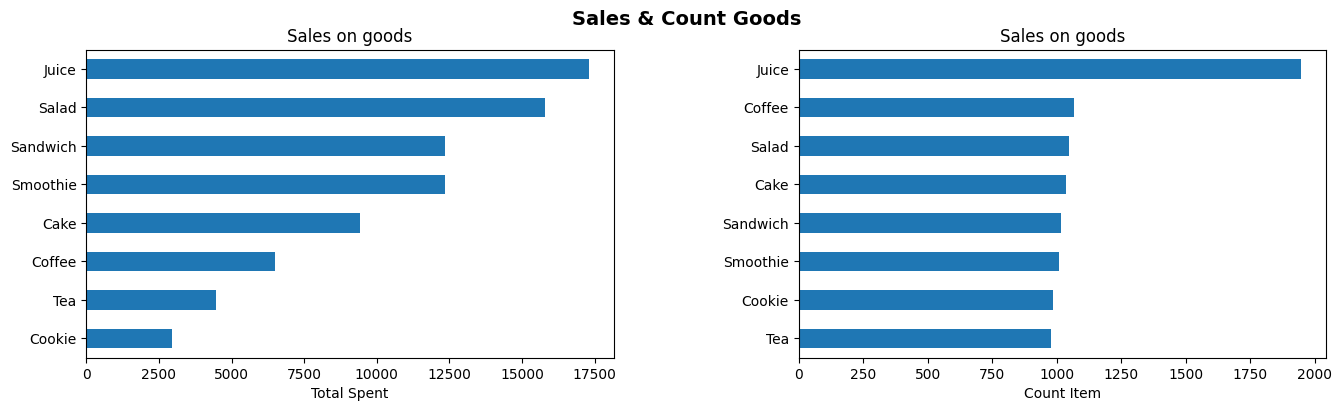

In [154]:
fig, axes = plt.subplots(1,2, figsize=(16,4))
fig.suptitle("Sales & Count Goods", fontsize=14, fontweight="bold")
plt.subplots_adjust(hspace=0.45, wspace=0.35)
# total_spent per item

ax = axes[0]  #axes [0,0]
df.groupby("item")["total_spent"].sum().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Sales on goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")
ax = axes[1]  #axes [0,1]
df["item"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Count on goods")
ax.set_xlabel("Count Item")
ax.set_ylabel("")
plt.show()

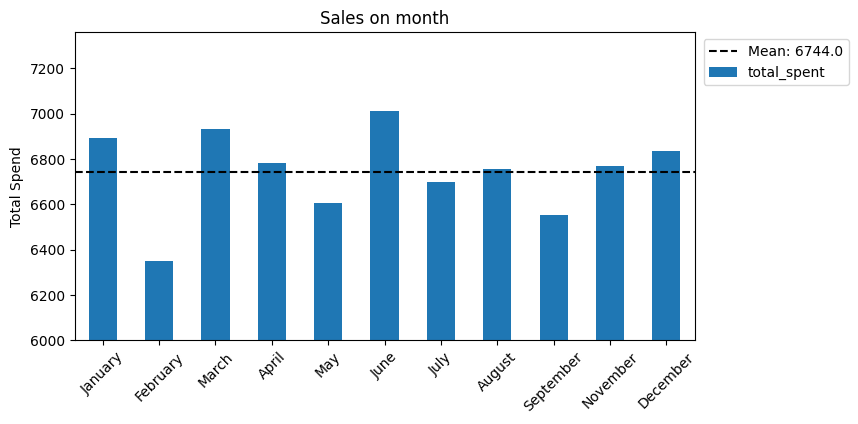

In [188]:
# Sales on month
fig = plt.figure(figsize=(8,4))
month_order = ["January", "February", "March", "April",
               "May", "June", "July", "August", "September", "Oktober", "November", "December"]
rev_month = df.groupby("month_name")["total_spent"].sum().reindex([m for m in month_order if m in df["month_name"].unique()])
rev_month.plot(kind="bar",rot=45)
mean_value = rev_month.mean()
std_value = rev_month.std()
std_pct = (std_value / mean_value)* 100


#print(mean_value)
plt.axhline(y=mean_value, color="black", linestyle="--", linewidth=1.5, label=f"Mean: {mean_value:.1f}")
plt.ylim(bottom=6000)
plt.title("Sales on moth")
plt.xlabel("")
plt.ylabel("Total Spend")
plt.title("Sales on month")
plt.legend(bbox_to_anchor=(1.26,1),loc="upper right")
#plt.text(1.01,0.6, f"std: {std_pct:.2f}%, transform=plt.gca().transAxes")
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## Saving a clean CSV for Tableau

In [195]:
#For Tableau better date format: YYYY-MM-DD
df["transaction_date"] = df['transaction_date'].dt.strftime('%Y-%m-%d')

AttributeError: Can only use .dt accessor with datetimelike values

In [197]:
# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True:'Yes',
    False: 'No'
})
#df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')
#print(f"Saved: {FILE_OUT}")
print(f"Rows: {len(df)}|Columns: {df.shape[1]}")
print(f"'Columns': {list(df.columns)}")

Rows: 9083|Columns: 16
'Columns': ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']
